## Data Import and Preparation
The **Data Import and Preparation** phase serves as the foundation of the forensic pipeline, where raw blockchain data is ingested and organized into predictive features and target labels. This step is crucial because machine learning models require a structured separation between observed behaviors—such as liquidity depth or wallet distributions—and the known outcomes (Rugpull vs. Safe) to identify fraud patterns effectively.

In [1]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset (produced by 01_Data_Pipeline/2_processing_and_graph.ipynb)
df = pd.read_csv(os.path.join("..", "01_Data_Pipeline", "processed_features.csv"))

# Split features and labels
X = df.drop("label", axis=1)
y = df["label"]


## Feature Scaling and Data Splitting
Scaling ensures that features with larger numerical ranges don't dominate the model. We use `stratify=y` to maintain the class balance (important for fraud detection where labels are often imbalanced).

In [2]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler to exported_models/
import joblib
os.makedirs("exported_models", exist_ok=True)
joblib.dump(scaler, os.path.join("exported_models", "scaler.joblib"))

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Model Initialization and Training
We use **CatBoost**, a gradient boosting library that handles categorical data well and is generally robust against overfitting. Recall is selected as the primary evaluation metric because in fraud detection, failing to identify a malicious contract (False Negative) can result in significant financial loss, making it more critical than incorrectly flagging legitimate contracts.

In [3]:
from catboost import CatBoostClassifier

# Note: the training set is ~48% fraud / 52% safe — nearly balanced.
# No class_weights are needed. Recall optimisation is handled AFTER training
# by the threshold sweep cell below (which finds the lowest threshold that
# still keeps Precision >= 20%).
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Recall',
    verbose=100
)

model.fit(X_train, y_train)


0:	learn: 0.9194631	total: 140ms	remaining: 41.9s
100:	learn: 0.9597315	total: 228ms	remaining: 450ms
200:	learn: 0.9865772	total: 318ms	remaining: 157ms
299:	learn: 0.9932886	total: 409ms	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='Recall', iterations=300, learning_rate=0.05, loss_function='Logloss', verbose=100)

## Evaluation and Peformance Metrics
This section calculates the **ROC-AUC** (to measure overall separation capability) and generates a **Classification Report** (to see precision, recall, and F1-score). These metrics mathematically prove how effectively the model distinguishes between safe and high-risk investments, providing the technical validation required for a security-focused tool before it is used to protect real-world funds.

In [4]:
from sklearn.metrics import roc_auc_score, recall_score, classification_report

# Predict probabilities and classes
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Evaluation
auc_val = roc_auc_score(y_test, y_pred_proba)
recall_val = recall_score(y_test, y_pred)

print(f"ROC-AUC Score: {auc_val:.4f}")
print(f"Recall Score: {recall_val:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.9671
Recall Score: 0.9474

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        40
           1       0.92      0.95      0.94        38

    accuracy                           0.94        78
   macro avg       0.94      0.94      0.94        78
weighted avg       0.94      0.94      0.94        78



## Performance Visuals
To move beyond simple numbers, this section provides intuitive proof through the ROC Curve and Confusion Matrix. These visuals demonstrate the model's accuracy and specific error types, such as false negatives, which are critical for fraud detection. The goal is to bridge the gap between technical metrics and business understanding, translating complex statistical data into an easy-to-understand format for stakeholders and investors.

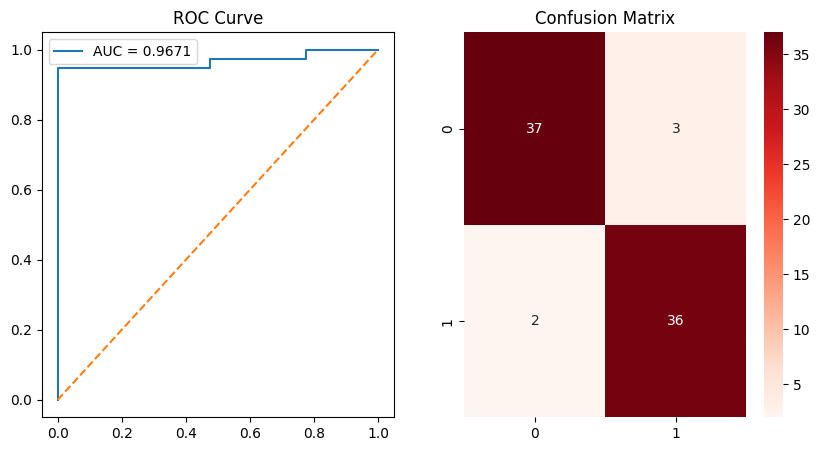

In [5]:
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.legend()

# Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix")
plt.show()

## Forensic Analysis
The Forensic Analysis section provides the explainability required for a "glass-box" security tool by ranking which blockchain behaviors most strongly suggest a rugpull. This turns the model from a mysterious black box into a transparent investigative assistant, providing users with specific reasons why a particular meme coin was flagged as high-risk.

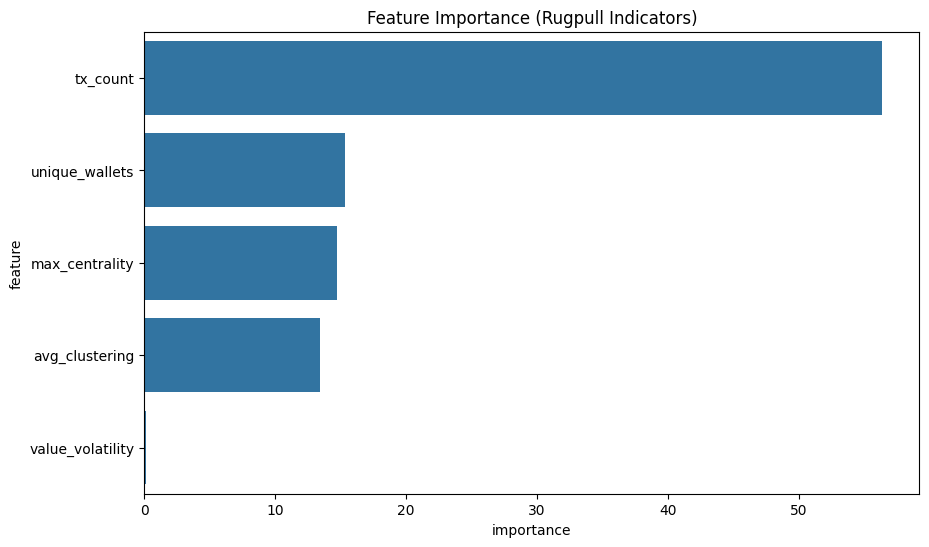

In [6]:
importance = model.get_feature_importance()
fi_df = pd.DataFrame({"feature": X.columns, "importance": importance}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=fi_df)
plt.title("Feature Importance (Rugpull Indicators)")
plt.show()

## Implementation &  Model Export 
Finally, we save the trained model to a binary file. This allows you to deploy the detector into a live environment or a web app without needing to retrain it.

In [7]:
# Save trained model
def predict_risk_score(model, X_input):
    return model.predict_proba(X_input)[:, 1] * 100

# Demo the risk score
print(f"Risk Scores for sample projects: {predict_risk_score(model, X_test[:5])}")

model.save_model(os.path.join("exported_models", "rugpull_detector.cbm"))
print("Model saved to exported_models/rugpull_detector.cbm")


Risk Scores for sample projects: [99.93848865 99.9555343  43.13961782 99.90471892  0.73509725]
Model saved to exported_models/rugpull_detector.cbm
